# Customer Shopping Behavior Analytics & Machine Learning

This notebook analyzes customer shopping behavior using Python, SQL, machine learning, customer segmentation, and SHAP explainability.

### Workflow
1. Load and inspect the dataset
2. Clean and transform the data
3. Explore customer behavior with visualizations
4. Build subscription-status classification models
5. Compare Logistic Regression, Random Forest, and XGBoost
6. Segment customers using K-Means clustering
7. Explain the best classification model using coefficients and SHAP
8. Export datasets for Power BI and further analysis

## 1. Setup & Imports

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Gradient boosting
from xgboost import XGBClassifier

# SHAP explainability
import shap

# Reproducibility / local CPU control
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

### Environment setup

If you are running this notebook in a fresh environment, install the required packages first:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap sqlalchemy psycopg2-binary
```

The notebook itself does not store passwords or other database credentials.

## 2. Load Dataset

In [2]:
df = pd.read_csv("customer_behavior.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 3. Understand the Dataset

In [3]:
# First five rows
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
# Last five rows
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
# Descriptive statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,NaN,NaN,NaN,1950.5,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,NaN,NaN,NaN,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0
Gender,3900,2,Male,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Purchased,3900,25,Blouse,171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,3900,4,Clothing,1737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase Amount (USD),3900.0,NaN,NaN,NaN,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0
Location,3900,50,Montana,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,3900,4,M,1755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,3900,25,Olive,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,3900,4,Spring,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Missing values
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

## 4. Data Cleaning & Feature Engineering

In [8]:
# Fill missing Review Rating values using the median rating within each category
df["Review Rating"] = (
    df.groupby("Category")["Review Rating"]
      .transform(lambda x: x.fillna(x.median()))
)

df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [9]:
# Standardize column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Make the purchase amount column easier to use
df = df.rename(columns={
    "purchase_amount_(usd)": "purchase_amount"
})

df.columns.tolist()

['customer_id',
 'age',
 'gender',
 'item_purchased',
 'category',
 'purchase_amount',
 'location',
 'size',
 'color',
 'season',
 'review_rating',
 'subscription_status',
 'shipping_type',
 'discount_applied',
 'promo_code_used',
 'previous_purchases',
 'payment_method',
 'frequency_of_purchases']

In [10]:
# Create age groups using quartiles
labels = ["Young Adult", "Adult", "Middle-aged", "Senior"]

df["age_group"] = pd.qcut(
    df["age"],
    q=4,
    labels=labels
)

df[["age", "age_group"]].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [11]:
# Convert purchase-frequency categories into approximate days
frequency_mapping = {
    "Fortnightly": 14,
    "Weekly": 7,
    "Monthly": 30,
    "Quarterly": 90,
    "Bi-Weekly": 14,
    "Annually": 365,
    "Every 3 Months": 90
}

df["purchase_frequency_days"] = (
    df["frequency_of_purchases"].map(frequency_mapping)
)

df[["purchase_frequency_days", "frequency_of_purchases"]].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [12]:
# Check whether Discount Applied and Promo Code Used contain the same information
df[["discount_applied", "promo_code_used"]].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [13]:
(df["discount_applied"] == df["promo_code_used"]).all()

np.True_

In [14]:
# Remove the redundant promo-code column
df = df.drop(columns=["promo_code_used"])

df.columns.tolist()

['customer_id',
 'age',
 'gender',
 'item_purchased',
 'category',
 'purchase_amount',
 'location',
 'size',
 'color',
 'season',
 'review_rating',
 'subscription_status',
 'shipping_type',
 'discount_applied',
 'previous_purchases',
 'payment_method',
 'frequency_of_purchases',
 'age_group',
 'purchase_frequency_days']

## 5. SQL Integration

The cleaned dataset can be loaded into PostgreSQL for SQL-based analysis.

**Security note:** database credentials should never be hard-coded in a public GitHub notebook. The example below asks for the password interactively.

In [ ]:
from sqlalchemy import create_engine
from getpass import getpass
from urllib.parse import quote_plus

username = input("PostgreSQL username [postgres]: ").strip() or "postgres"
password = getpass("PostgreSQL password: ")
host = input("PostgreSQL host [localhost]: ").strip() or "localhost"
port = input("PostgreSQL port [5432]: ").strip() or "5432"
database = input("Database name [customer_1]: ").strip() or "customer_1"

password_encoded = quote_plus(password)

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password_encoded}@{host}:{port}/{database}"
)

table_name = "customer"

df.to_sql(
    table_name,
    engine,
    if_exists="replace",
    index=False
)

print(f"Data successfully loaded into table '{table_name}'.")

## 6. Exploratory Data Visualizations

### Gender-Based Customer Distribution

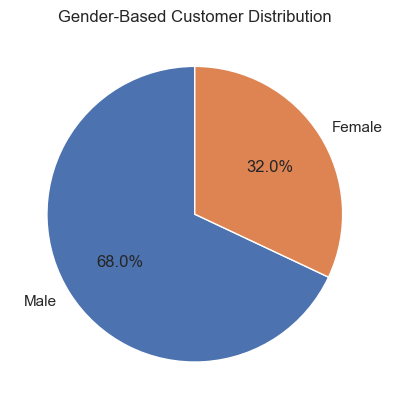

In [16]:
gender_counts = df["gender"].value_counts()

gender_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender-Based Customer Distribution")
plt.ylabel("")
plt.show()

### Purchase Frequency by Age Group

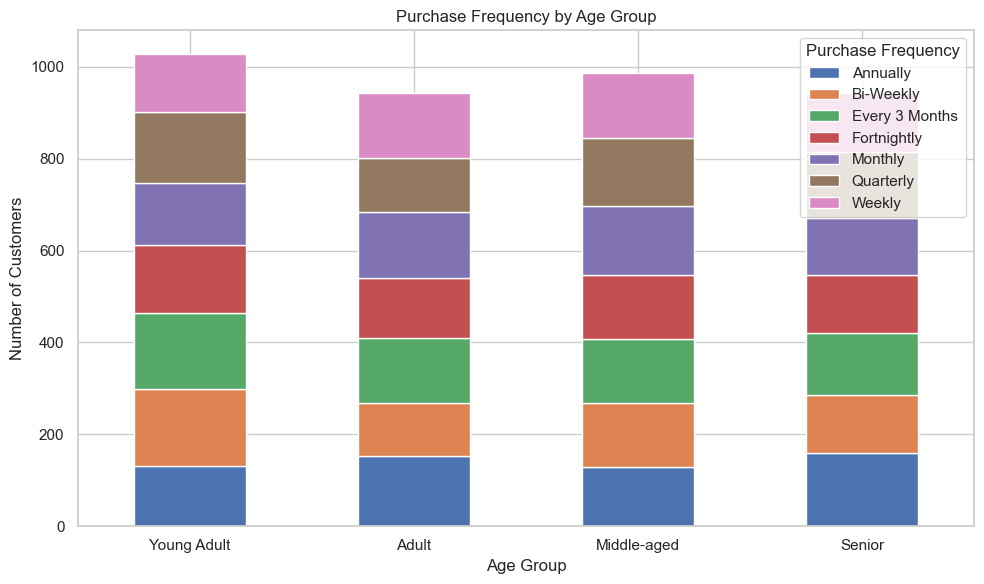

In [17]:
pd.crosstab(
    df["age_group"],
    df["frequency_of_purchases"]
).plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Purchase Frequency by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Purchase Frequency")
plt.tight_layout()
plt.show()

### Payment Method Distribution

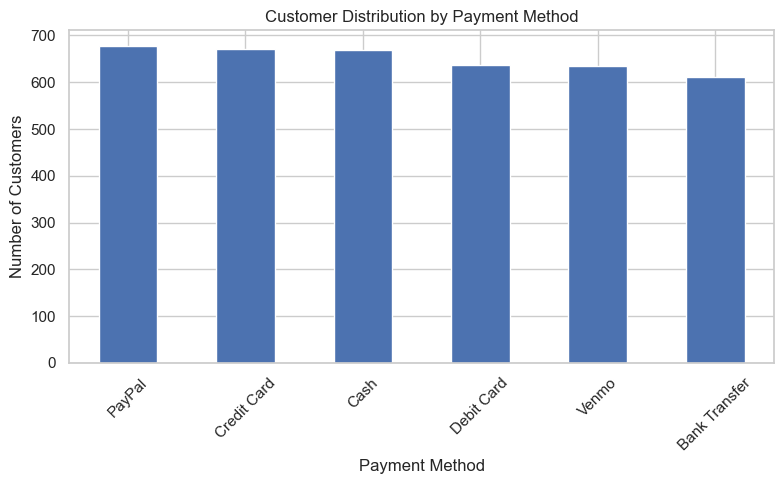

In [18]:
payment_counts = df["payment_method"].value_counts()

payment_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Payment Method vs Subscription Status

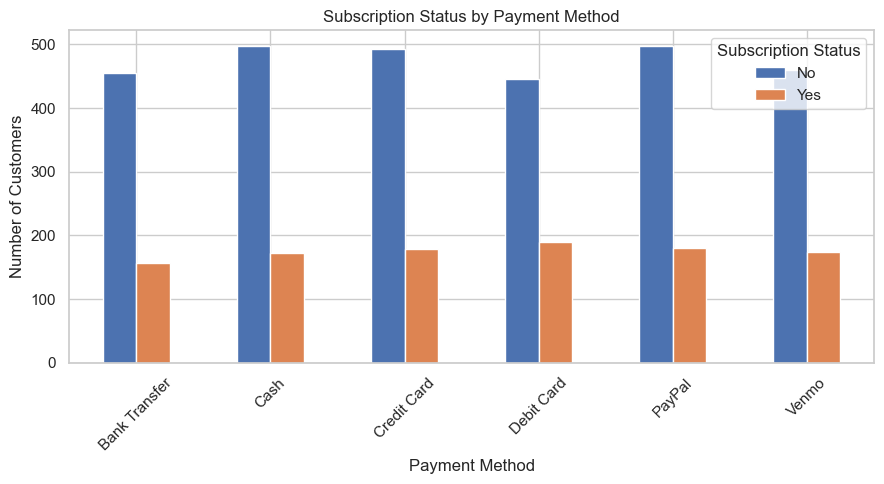

In [19]:
pd.crosstab(
    df["payment_method"],
    df["subscription_status"]
).plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Subscription Status by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.legend(title="Subscription Status")
plt.tight_layout()
plt.show()

## 7. Subscription Status Classification

The target variable is `subscription_status`.

- `Yes` → 1
- `No` → 0

The model uses demographic, purchase, and shopping-behavior features to classify the **observed subscription status**.

In [20]:
df["subscription_status"] = (
    df["subscription_status"]
      .map({"Yes": 1, "No": 0})
)

features = [
    "age",
    "gender",
    "category",
    "purchase_amount",
    "location",
    "size",
    "color",
    "season",
    "review_rating",
    "shipping_type",
    "discount_applied",
    "previous_purchases",
    "payment_method",
    "purchase_frequency_days"
]

X = df[features]
y = df["subscription_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (3120, 14)
Test set: (780, 14)


### Preprocessing

In [21]:
numeric_features = [
    "age",
    "purchase_amount",
    "review_rating",
    "previous_purchases",
    "purchase_frequency_days"
]

categorical_features = [
    "gender",
    "category",
    "location",
    "size",
    "color",
    "season",
    "shipping_type",
    "discount_applied",
    "payment_method"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

## 8. Model Training

In [22]:
# Logistic Regression
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'purchase_amount',
                                                   'review_rating',
                                                   'previous_purchases',
                                                   'purchase_frequency_days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'category',
                                                   'location', 'size', 'color',
                                                   'season', 'shipping_type',
                                                   'discount_applied',
                                                   'payment_method'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [23]:
# Random Forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'purchase_amount',
                                                   'review_rating',
                                                   'previous_purchases',
                                                   'purchase_frequency_days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'category',
                                                   'location', 'size', 'color',
                                                   'season', 'shipping_type',
                                                   'discount_applied',
                                                   'payment_method'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [24]:
# XGBoost
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'purchase_amount',
                                                   'review_rating',
                                                   'previous_purchases',
                                                   'purchase_frequency_days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'category',
                                                   'location', 'size', 'color',
                                                   'season', 'shipping_type',
                                                   'discount_applied',
                                                   'payment_method'])])),
                ('model',
                 XGBC...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

## 9. Model Comparison

In [25]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():
    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "F1 Score": f1_score(y_test, prediction),
        "ROC-AUC": roc_auc_score(y_test, probability)
    })

results_df = pd.DataFrame(results)
results_df.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.857692,0.683824,0.881517,0.770186,0.911852
1,Random Forest,0.850000,0.663194,0.905213,0.765531,0.911119
2,XGBoost,0.839744,0.669291,0.805687,0.731183,0.907829


## 10. Best Model Evaluation

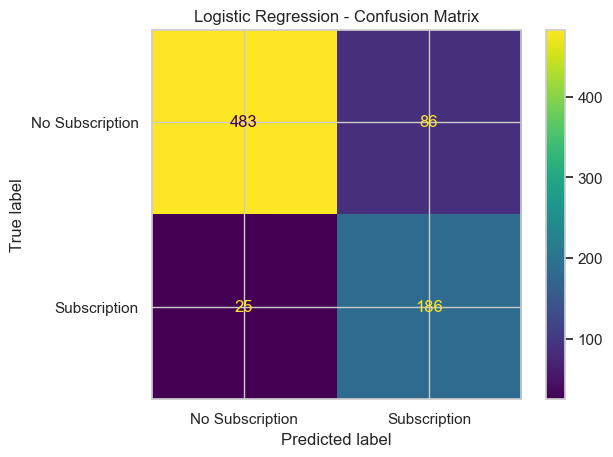

In [26]:
best_model = lr_model

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Subscription", "Subscription"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Logistic Regression Coefficients

In [27]:
feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    best_model
    .named_steps["model"]
    .coef_[0]
)

coefficient_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_importance["Absolute_Importance"] = (
    coefficient_importance["Coefficient"].abs()
)

coefficient_importance = coefficient_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

coefficient_importance.head(15)

,Feature,Coefficient,Absolute_Importance
100,cat__discount_applied_No,-3.227776,3.227776
101,cat__discount_applied_Yes,3.178329,3.178329
59,cat__location_Wisconsin,-0.751863,0.751863
5,cat__gender_Female,-0.653418,0.653418
24,cat__location_Indiana,-0.636061,0.636061
27,cat__location_Kentucky,0.613848,0.613848
47,cat__location_Oregon,-0.604762,0.604762
6,cat__gender_Male,0.603971,0.603971
38,cat__location_Nevada,0.549276,0.549276
18,cat__location_Delaware,0.535123,0.535123


## 11. K-Means Customer Segmentation

K-Means is used to identify groups of customers with similar behavioral characteristics.

Features:
- Age
- Purchase Amount
- Review Rating
- Previous Purchases
- Purchase Frequency in Days

In [28]:
cluster_features = [
    "age",
    "purchase_amount",
    "review_rating",
    "previous_purchases",
    "purchase_frequency_days"
]

X_cluster = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

### Elbow Method

In [29]:
inertia = []

for k in range(2, 8):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

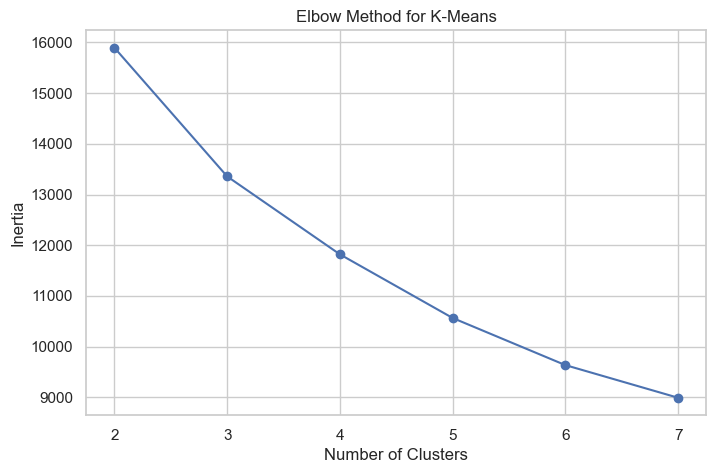

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 8),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

### Final K-Means Model

In [31]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["customer_cluster"] = kmeans.fit_predict(X_scaled)

df["customer_cluster"].value_counts().sort_index()

customer_cluster
0    1224
1     980
2     572
3    1124
Name: count, dtype: int64

In [32]:
cluster_summary = df.groupby("customer_cluster").agg({
    "age": "mean",
    "purchase_amount": "mean",
    "review_rating": "mean",
    "previous_purchases": "mean"
}).round(2)

cluster_summary["customer_count"] = (
    df["customer_cluster"].value_counts()
)

cluster_summary

,age,purchase_amount,review_rating,previous_purchases,customer_count
customer_cluster,,,,,
0,41.49,59.38,3.73,10.15,1224
1,30.25,60.01,3.81,35.42,980
2,44.67,60.17,3.76,24.56,572
3,58.62,59.76,3.71,33.53,1124


### Customer Segmentation Visualization

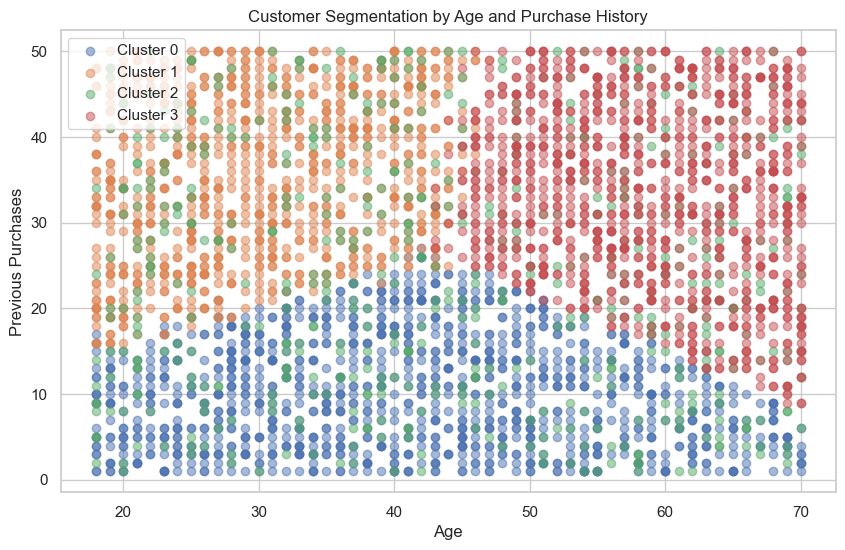

In [33]:
plt.figure(figsize=(10, 6))

for cluster in sorted(df["customer_cluster"].unique()):
    cluster_data = df[df["customer_cluster"] == cluster]

    plt.scatter(
        cluster_data["age"],
        cluster_data["previous_purchases"],
        label=f"Cluster {cluster}",
        alpha=0.5
    )

plt.xlabel("Age")
plt.ylabel("Previous Purchases")
plt.title("Customer Segmentation by Age and Purchase History")
plt.legend()
plt.show()

## 12. SHAP Explainability

SHAP (SHapley Additive exPlanations) is used to understand which transformed features contribute most to the Logistic Regression model's predictions.

`cat__` represents one-hot encoded categorical features, while `num__` represents scaled numerical features.

In [34]:
preprocessor = best_model.named_steps["preprocessor"]
classifier = best_model.named_steps["model"]

X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Transformed test shape:", X_test_transformed.shape)
print("Number of features:", len(feature_names))

Transformed test shape: (780, 108)
Number of features: 108


In [35]:
explainer = shap.LinearExplainer(
    classifier,
    X_test_transformed
)

shap_values = explainer.shap_values(
    X_test_transformed
)

Background dataset has 780 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=780 when initializing the masker.


### SHAP Summary Plot

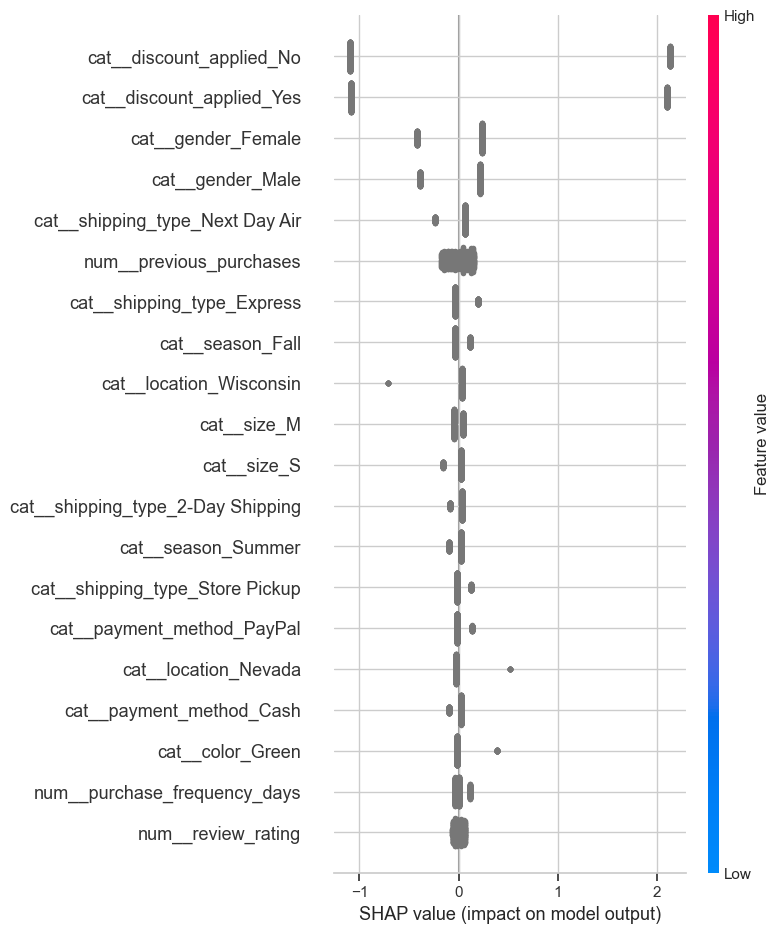

In [36]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

### Top SHAP Feature Importance

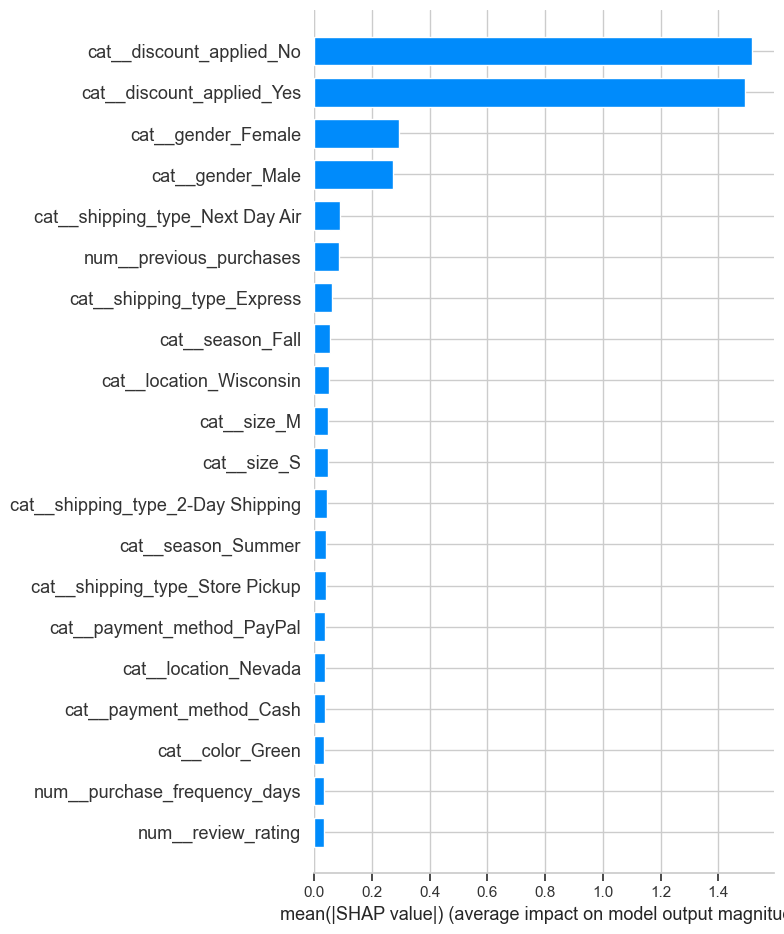

In [37]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [38]:
# Create a reusable SHAP importance table
shap_array = (
    shap_values.toarray()
    if hasattr(shap_values, "toarray")
    else np.asarray(shap_values)
)

if shap_array.ndim > 2:
    shap_array = shap_array[..., 0]

shap_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Abs_SHAP": np.abs(shap_array).mean(axis=0)
}).sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

shap_feature_importance.head(10)

,Feature,Mean_Abs_SHAP
100,cat__discount_applied_No,1.517220
101,cat__discount_applied_Yes,1.493977
5,cat__gender_Female,0.294574
6,cat__gender_Male,0.272283
97,cat__shipping_type_Next Day Air,0.089878
3,num__previous_purchases,0.085237
95,cat__shipping_type_Express,0.062017
90,cat__season_Fall,0.055878
59,cat__location_Wisconsin,0.050606
62,cat__size_M,0.047753


## 13. Export Analysis Outputs

In [39]:
# Main dataset with customer cluster labels
df.to_csv(
    "customer_behavior_ml.csv",
    index=False
)

# Model performance comparison
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

# Customer cluster summary
cluster_summary.to_csv(
    "cluster_summary.csv",
    index=False
)

# SHAP feature importance
shap_feature_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

# Logistic Regression coefficient importance
coefficient_importance.to_csv(
    "logistic_coefficient_importance.csv",
    index=False
)

print("Analysis files exported successfully.")

Analysis files exported successfully.


## 14. Key Takeaways

- Customer demographics and shopping behavior can be analyzed using Python and SQL.
- Logistic Regression, Random Forest, and XGBoost were evaluated for subscription-status classification.
- K-Means was used to segment customers based on behavioral characteristics.
- SHAP provides model explainability and identifies the features most influential to subscription-status classification.
- The exported CSV files can be connected to Power BI for interactive dashboarding.